## Tutorial 1 Querying niches on simulation data

To evaluate the niche query performance under niche-level topological and environmental variations, we simulated a spatial transcriptomics dataset with two samples with scCube. 

In [ ]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
import sys
import logging
import warnings
import scanpy as sc
import matplotlib.pyplot as plt

In [ ]:
import sys, os
import quest.utils as utils
from quest.trainer import QueSTTrainer

In [ ]:
warnings.filterwarnings("ignore")
logger = logging.getLogger(__name__)
logging.basicConfig(level=logging.WARNING)

### Read and explore the data

In [ ]:
data_path = "../data/Simulation"
model_path = "../results/Simulation/model/quest_model.pth"
sample_ids = ["Sample1", "Sample2"]
adata_list = [sc.read_h5ad(f"{data_path}/{data_id}.h5ad") for data_id in sample_ids]

In each sample, we first simulated heterogeneous background cell types. Sample-1 (S1) featured endothelial cells, while Sample-2 (S2) featured macrophage/monocyte cells as backgrounds. Then, we created three niche types within the background. The key differences between these niches lay in cell type composition (T-edge, T-core and B-edge) and topological structure (T-edge vs T-core). T-edge niches had Cancer/Epithelial cells at the inner core and T-cells in the outer edge; T-core niches had the reverse structure, with T-cells at the inner core and Cancer/Epithelial cells in the outer edge; B-edge niches consisted of Cancer/Epithelial cells at the inner core and B-cells in the outer edge. Here we show the niches of interest (NOI) on Sample1 and their corresponding target niches on Sample2.

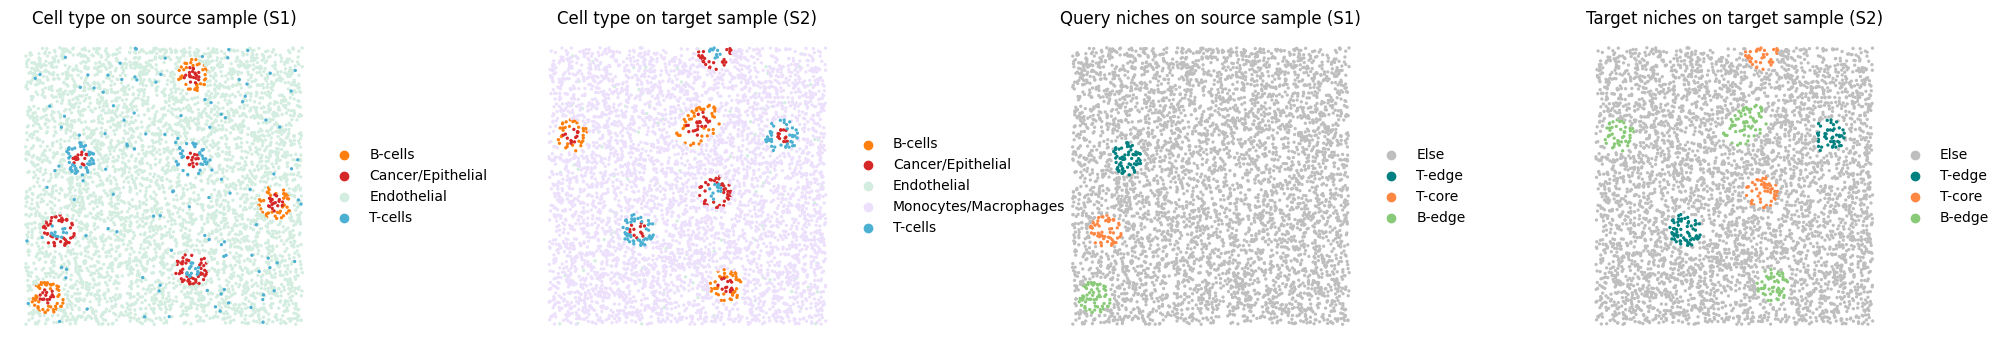

In [ ]:
fig, axes = plt.subplots(ncols=4, nrows=1, figsize=(20, 4))
axes = axes.flatten()
adata_source, adata_target = adata_list[0], adata_list[1]
sc.pl.spatial(adata_source, color="cell_type", spot_size=0.6, ax=axes[0], show=False, title="Cell type on source sample (S1)", palette=utils.color_simulation)
sc.pl.spatial(adata_target, color="cell_type", spot_size=0.6, ax=axes[1], show=False, title="Cell type on target sample (S2)", palette=utils.color_simulation)
sc.pl.spatial(adata_source, color="niche of interest", spot_size=0.6, ax=axes[2], show=False, title="Query niches on source sample (S1)", palette=utils.color_simulation)
sc.pl.spatial(adata_target, color="target niche", spot_size=0.6, ax=axes[3], show=False, title="Target niches on target sample (S2)", palette=utils.color_simulation)
for i in range(len(axes)):
    axes[i].set_axis_off() 
    axes[i].invert_yaxis()
fig.tight_layout()
fig.show()

### Configure niche query task

In [ ]:
dataset = "Simulation"
query_sample_id = "Sample1"
query_niches = ['T-edge_niche', 'T-core_niche', 'B-edge_niche']

### Set up QueST Trainer

Since scCube directly simulated normalized gene expression, normalization is not needed here. 

In [ ]:
trainer = QueSTTrainer(dataset=dataset, data_path=data_path, sample_ids=sample_ids, adata_list=adata_list, 
                       query_niches=query_niches, query_sample_id=query_sample_id, 
                       model_path=model_path, 
                       epochs=20, save_model=True, hvg=None, min_count=0, normalize=False)

### Train QueST model and perform niche query

We also provided pretrained QueST model checkpoint weights at https://cloud.tsinghua.edu.cn/d/b26449d093bb4b57a0c0/. To skip training and use pretrained checkpoint, simiply put it at corresponding model path and comment the "trainer.train()" line.

In [ ]:
trainer.train()
trainer.inference(ckpt_path=model_path, save_embedding=False, query=True)

training: 100%|██████████| 20/20 [01:14<00:00,  3.75s/epoch]


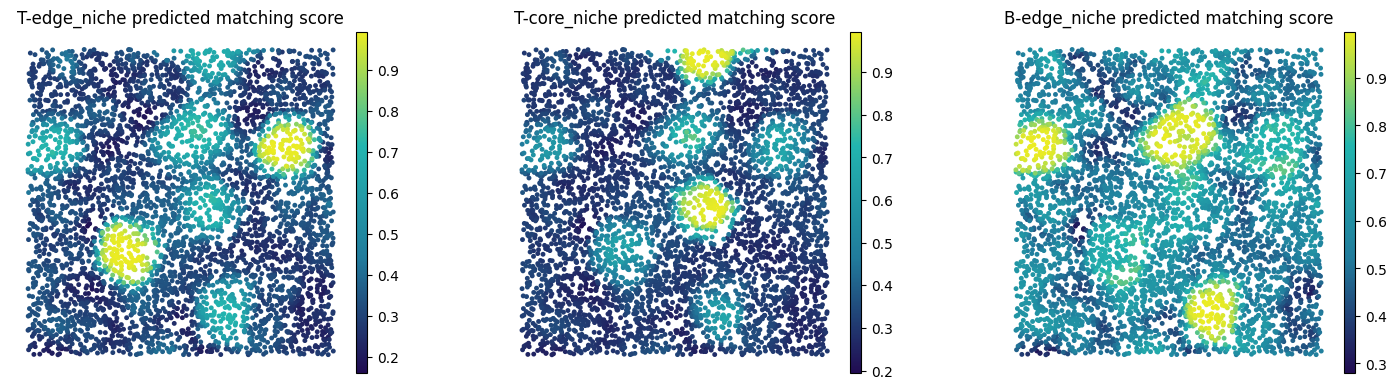

In [ ]:
from matplotlib.colors import LinearSegmentedColormap
custom_cmap = LinearSegmentedColormap.from_list("custom", ["#210c52", "#217b9c", "#22b5af", "#ebec23"])

fig, axes = plt.subplots(ncols=len(query_niches), nrows=1, figsize=(5 * len(query_niches), 4))
axes = axes.flatten()
adata_target = trainer.adata_ref_list[0]
for i, query_niche in enumerate(query_niches):
    sc.pl.spatial(adata_target, color=f"{query_niche} predicted matching score", ax=axes[i], show=False, spot_size=0.8,
                  title=f"{query_niche} predicted matching score", cmap=custom_cmap)
    axes[i].set_axis_off()
    axes[i].invert_yaxis()
fig.tight_layout()
fig.show()